# `01_imputar_dataset.ipynb` — Dataset final imputado

**Etapa 6 — Pós-imputação · notebook 1 de 3**

## Objetivo

Aplicar o **modelo final** (`gain_best.pt`, Etapa 4) a **todo o dataset** (639 coletas,
2012–2025 — não só o test) e produzir o **`WaterQualityImputed.parquet`**: o dataset
completo, sem valores faltantes nas 11 variáveis de qualidade da água, pronto para as
análises ambientais das próximas etapas (IQA, tendências).

> **Pergunta:** qual o resultado final do projeto — o dataset imputado pronto para uso?

## ⚠️ Aviso de uso — leia antes de consumir o dataset

Os valores imputados são **estimativas estatísticas de um modelo**, não medições. Cada
variável traz uma coluna companheira **`<Var>_imputed_flag`** (`True` = valor imputado
pela GAIN, `False` = medição original do INEA). **Sempre filtre por essa flag** antes de
qualquer análise que exija dados medidos. A avaliação da Etapa 5 mostrou que a GAIN
**iguala o melhor baseline clássico (KNN)** no test, com **compressão moderada de caudas** —
logo os imputados tendem a ser conservadores (puxados para o centro condicional);
não confie neles para detectar extremos (picos de eutrofização, eventos).

## Adaptações em relação ao plano (`Pipeline/06_PostImputation/01_imputar_dataset.md`)

- **639 linhas e 11 variáveis** (não 657×13): a base foi reduzida em 2026-06-29 para
  6 estações e 11 variáveis. `Coliformes` **entra** aqui (tem 476 observações no dataset
  completo, embora 0 no test).
- **Não reexecutamos a Etapa 2 a partir do `.xlsx`.** O dataset já processado de forma
  idêntica ao treino da GAIN é `Data/ProcessedData/dataset_normalizado.parquet` (é dele
  que os splits foram derivados) — usá-lo garante consistência bit-a-bit com o modelo.
- **Células observadas vêm do valor físico ORIGINAL** — `WaterQualityInitialData.xlsx`
  (escala real do INEA, alinhado linha a linha às 639 coletas): as medições entram
  **verbatim** (erro zero). Só as células `M=0` recebem a estimativa da GAIN.
  *Não* usamos `dataset_com_tempo.parquet` como fonte física — ele está em espaço
  Box-Cox/Yeo-Johnson (Nitrato/Fósforo negativos), o que misturaria escalas com os
  imputados. Como o `MinMaxScaler` foi ajustado no dataset **completo** (leakage suave,
  Etapa 2), `desnormalizar` é um round-trip exato (~1e-9) — confirmado na seção 5.
- Saídas em `Data/ImputedData/`, `Data/Figures/06_PostImputation/`,
  `Code/7 - PostImputation/tabelas/`.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "Data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CODE = ROOT / "Code"
sys.path.insert(0, str(CODE / "4 - Baseline"))   # baseline_utils.desnormalizar
sys.path.insert(0, str(CODE / "5 - GAIN"))       # gain
import gain
import baseline_utils as bu

PROC_DIR = ROOT / "Data/ProcessedData"
RAW_XLSX = ROOT / "Data/IntermediaryData/WaterQualityInitialData.xlsx"
CKPT     = CODE / "5 - GAIN/checkpoints/gain_best.pt"
OUT_PARQUET = ROOT / "Data/ImputedData/WaterQualityImputed.parquet"
OUT_TAB = CODE / "7 - PostImputation/tabelas"
OUT_FIG = ROOT / "Data/Figures/06_PostImputation"
for d in (OUT_PARQUET.parent, OUT_TAB, OUT_FIG):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 180)

# Modelo GAIN (checkpoint local da Etapa 4 — confiável; weights_only=False p/ ler
# hp/vars/context_cols junto dos tensores)
ck = torch.load(CKPT, map_location="cpu", weights_only=False)
VARS         = ck["vars"]
CONTEXT_COLS = ck["context_cols"]
G = gain.Generator(len(VARS), len(CONTEXT_COLS), ck["hp"]["hidden"])
G.load_state_dict(ck["G_state"]); G.eval()

scalers = joblib.load(PROC_DIR / "scalers.pkl")
with open(PROC_DIR / "transform_params.json", encoding="utf-8") as f:
    transform_params = json.load(f)
print(f"GAIN carregada | {len(VARS)} variáveis-alvo | {len(CONTEXT_COLS)} de contexto")

GAIN carregada | 11 variáveis-alvo | 23 de contexto


## 3. Dataset completo já preparado (Etapa 2 aplicada ao todo)

Sem split aqui: usamos o **dataset inteiro** como entrada da imputação final.
`dataset_normalizado.parquet` (639×36) é a saída completa da Etapa 2 — mesmas
transformações, features temporais, encoding e normalização usadas no treino.
O **valor físico original** das medições + identificadores (`Local`, `Codigo Local`,
`Data`, `Ano`) + os `_LD` categóricos (censura à esquerda/direita) vêm de
`WaterQualityInitialData.xlsx` (escala real do INEA), alinhado linha a linha (639 coletas).
⚠️ `dataset_com_tempo.parquet` **não** serve como fonte física: está em espaço Box-Cox.

In [2]:
norm = pd.read_parquet(PROC_DIR / "dataset_normalizado.parquet")

# Fonte FÍSICA das células observadas: o dataset ORIGINAL do INEA (escala real),
# alinhado linha a linha às 639 coletas. NÃO usar dataset_com_tempo.parquet: ele está
# em espaço Box-Cox/Yeo-Johnson (Nitrato/Fósforo ficam negativos) — misturaria escalas
# entre observado (transformado) e imputado (físico) no dataset final.
orig = pd.read_excel(RAW_XLSX)
assert len(norm) == len(orig) and \
    (pd.to_datetime(norm["Data"]).values == pd.to_datetime(orig["Data"]).values).all(), \
    "normalizado e original desalinhados"
assert norm[CONTEXT_COLS].notna().all().all(), "contexto com NaN — violaria a GAIN"

# Máscara real do dataset completo (1 = observado)
M = (~norm[VARS].isna())

# Colunas físicas podem vir como texto no xlsx — coagir p/ numérico e garantir que
# toda célula observada (M=1) tem valor físico medido.
for v in VARS:
    orig[v] = pd.to_numeric(orig[v], errors="coerce")
    assert orig[v][M[v].values].notna().all(), f"{v}: célula observada sem valor físico"

x_full = torch.tensor(norm[VARS].fillna(0.0).to_numpy(dtype=np.float32))
m_full = torch.tensor(M.to_numpy(dtype=np.float32))
ctx_full = torch.tensor(norm[CONTEXT_COLS].to_numpy(dtype=np.float32))

n_total = M.size
n_missing = int((~M).sum().sum())
print(f"coletas: {len(norm)} | células-alvo: {n_total} | faltantes a imputar: "
      f"{n_missing} ({100*n_missing/n_total:.1f}%)")
print("\nobservados por variável (de 639):")
print(M.sum().to_string())

coletas: 639 | células-alvo: 7029 | faltantes a imputar: 1259 (17.9%)

observados por variável (de 639):
DBO                           624
OD                            618
Nitrato                       337
Nitrogênio Amoniacal Total    491
Fósforo Total                 606
Condutividade                 617
pH                            621
Turbidez                      613
Temperatura da Água           611
Sólidos Suspensos Totais      156
Coliformes Termotolerantes    476


## 4. Aplicar a GAIN ao dataset completo

`gain.impute` devolve `M ⊙ X + (1−M) ⊙ G(x̃, contexto, M)`: **preserva** as células
observadas (`M=1`) e preenche só as faltantes (`M=0`). Determinístico (ruído zero na
inferência — queremos a estimativa central).

In [3]:
with torch.no_grad():
    x_imp_norm = gain.impute(G, x_full, m_full, ctx_full).numpy()
imp_norm = pd.DataFrame(x_imp_norm, columns=VARS, index=norm.index)
print(f"imputação concluída no espaço normalizado: {imp_norm.shape}")
print(f"faixa dos valores imputados (M=0): "
      f"[{imp_norm.where(~M).min().min():.3f}, {imp_norm.where(~M).max().max():.3f}]  (esperado ⊂ [-1,1])")

imputação concluída no espaço normalizado: (639, 11)
faixa dos valores imputados (M=0): [-0.950, 0.699]  (esperado ⊂ [-1,1])


## 5. Inverter para a escala física

`desnormalizar` faz `clip[-1,1] → MinMax⁻¹ → Box-Cox/Yeo-Johnson⁻¹`. Aplicamos à saída da
GAIN para levar os **imputados** à escala original.

**O round-trip é exato aqui.** O `MinMaxScaler` foi ajustado no dataset **completo**
(decisão "leakage suave" da Etapa 2), não só no train — logo nenhuma medição sai de
`[-1,1]` e o `clip` não trunca nada. O diagnóstico abaixo confirma: `desnormalizar`
reproduz o valor físico original das observadas a **~1e-9**. Ainda assim, na seção 6 as
células `M=1` vêm do **valor físico original** (xlsx) verbatim — erro exatamente zero — e
só as `M=0` usam a saída invertida da GAIN.

In [4]:
imp_orig = bu.desnormalizar(imp_norm, VARS, scalers, transform_params)

# Sanidade da inversão: desnormalizar(observadas) deve reproduzir o valor físico original.
# O MinMaxScaler foi ajustado no dataset COMPLETO (decisão "leakage suave" da Etapa 2),
# então nenhuma medição sai de [-1,1] e o clip não trunca — o round-trip bate a ~1e-9,
# confirmando que a inversão está correta. (Mesmo assim usamos o valor físico original
# verbatim nas observadas na seção 6 — erro exatamente zero.)
deno_obs = bu.desnormalizar(norm[VARS], VARS, scalers, transform_params)
diag = []
for v in VARS:
    mv = M[v].values
    a = deno_obs[v].values[mv]; b = orig[v].values[mv]
    ok = ~np.isnan(a) & ~np.isnan(b)
    diag.append({"variavel": v, "tipo_transform": transform_params[v]["tipo"],
                 "max_erro_roundtrip_obs": float(np.max(np.abs(a[ok]-b[ok]))) if ok.any() else np.nan})
print("Round-trip nas observadas vs valor físico original (deve ser ~1e-9):")
pd.DataFrame(diag)

Round-trip nas observadas vs valor físico original (deve ser ~1e-9):


,variavel,tipo_transform,max_erro_roundtrip_obs
0,DBO,yeo-johnson,1.705303e-13
1,OD,yeo-johnson,1.065814e-14
2,Nitrato,boxcox,5.151435e-14
3,Nitrogênio Amoniacal Total,yeo-johnson,6.394885e-14
4,Fósforo Total,boxcox,6.366463e-12
5,Condutividade,identidade,1.818989e-12
6,pH,identidade,1.776357e-15
7,Turbidez,boxcox,2.046363e-12
8,Temperatura da Água,identidade,3.552714e-15
9,Sólidos Suspensos Totais,boxcox,2.273737e-13


## 6. Construir o dataset final

Regra: **valor físico original onde `M=1`; estimativa da GAIN onde `M=0`.** Cada variável
ganha `<Var>_imputed_flag` (`True` onde foi imputado). Ordem de colunas: identificadores →
11 variáveis → 11 flags → 11 `_LD` (auditoria de censura).

In [5]:
IDENT = ["Local", "Codigo Local", "Data", "Ano"]
LD_COLS = [f"{v}_LD" for v in VARS]

final = orig[IDENT].copy()
for v in VARS:
    mv = M[v].values
    final[v] = np.where(mv, orig[v].values, imp_orig[v].values)
for v in VARS:
    final[f"{v}_imputed_flag"] = (~M[v]).values
for v in VARS:
    final[LD_COLS[VARS.index(v)]] = orig[f"{v}_LD"].values

print(f"dataset final: {final.shape[0]} linhas × {final.shape[1]} colunas")
print("ordem de colunas:")
print(" | ".join(final.columns))

dataset final: 639 linhas × 37 colunas
ordem de colunas:
Local | Codigo Local | Data | Ano | DBO | OD | Nitrato | Nitrogênio Amoniacal Total | Fósforo Total | Condutividade | pH | Turbidez | Temperatura da Água | Sólidos Suspensos Totais | Coliformes Termotolerantes | DBO_imputed_flag | OD_imputed_flag | Nitrato_imputed_flag | Nitrogênio Amoniacal Total_imputed_flag | Fósforo Total_imputed_flag | Condutividade_imputed_flag | pH_imputed_flag | Turbidez_imputed_flag | Temperatura da Água_imputed_flag | Sólidos Suspensos Totais_imputed_flag | Coliformes Termotolerantes_imputed_flag | DBO_LD | OD_LD | Nitrato_LD | Nitrogênio Amoniacal Total_LD | Fósforo Total_LD | Condutividade_LD | pH_LD | Turbidez_LD | Temperatura da Água_LD | Sólidos Suspensos Totais_LD | Coliformes Termotolerantes_LD


## 7. Validações e resumo da imputação

Confirma ausência de `NaN` e compara `mean_original` (só observados) vs `mean_imputado`
(só imputados) por variável — diferenças grandes sinalizam viés da imputação.

In [6]:
n_nan = int(final[VARS].isna().sum().sum())
print(f"NaN nas {len(VARS)} variáveis: {n_nan}  ->  {'OK (zero)' if n_nan==0 else 'FALHA'}")
assert n_nan == 0

linhas = []
for v in VARS:
    mv = M[v].values
    orig_obs = orig[v].values[mv]
    imp_val  = imp_orig[v].values[~mv]
    linhas.append({
        "variavel": v,
        "n_original": int(mv.sum()),
        "n_imputado": int((~mv).sum()),
        "pct_imputado": round(100 * (~mv).sum() / len(mv), 1),
        "mean_original": float(np.nanmean(orig_obs)) if mv.any() else np.nan,
        "mean_imputado": float(np.nanmean(imp_val)) if (~mv).any() else np.nan,
    })
resumo = pd.DataFrame(linhas)
resumo["razao_media"] = (resumo["mean_imputado"] / resumo["mean_original"]).round(3)
resumo.to_csv(OUT_TAB / "imputacao_resumo.csv", index=False, encoding="utf-8")
print(f"salvo: {(OUT_TAB / 'imputacao_resumo.csv').name}")
resumo.round(3)

NaN nas 11 variáveis: 0  ->  OK (zero)
salvo: imputacao_resumo.csv


,variavel,n_original,n_imputado,pct_imputado,mean_original,mean_imputado,razao_media
0,DBO,624,15,2.3,16.701,15.913,0.953
1,OD,618,21,3.3,5.123,4.644,0.907
2,Nitrato,337,302,47.3,0.182,0.047,0.261
3,Nitrogênio Amoniacal Total,491,148,23.2,5.010,5.343,1.067
4,Fósforo Total,606,33,5.2,7.940,0.932,0.117
5,Condutividade,617,22,3.4,18664.576,16693.057,0.894
6,pH,621,18,2.8,7.853,7.807,0.994
7,Turbidez,613,26,4.1,39.777,40.549,1.019
8,Temperatura da Água,611,28,4.4,24.773,25.709,1.038
9,Sólidos Suspensos Totais,156,483,75.6,52.609,43.672,0.830


## 8. Distribuição: observado vs imputado

Por variável, os valores **observados** (cinza) e **imputados** (vermelho). Sobreposição =
imputação plausível; imputados concentrados numa faixa estreita = compressão / mode collapse
residual. Eixo-x cortado no intervalo 1–99% dos observados.

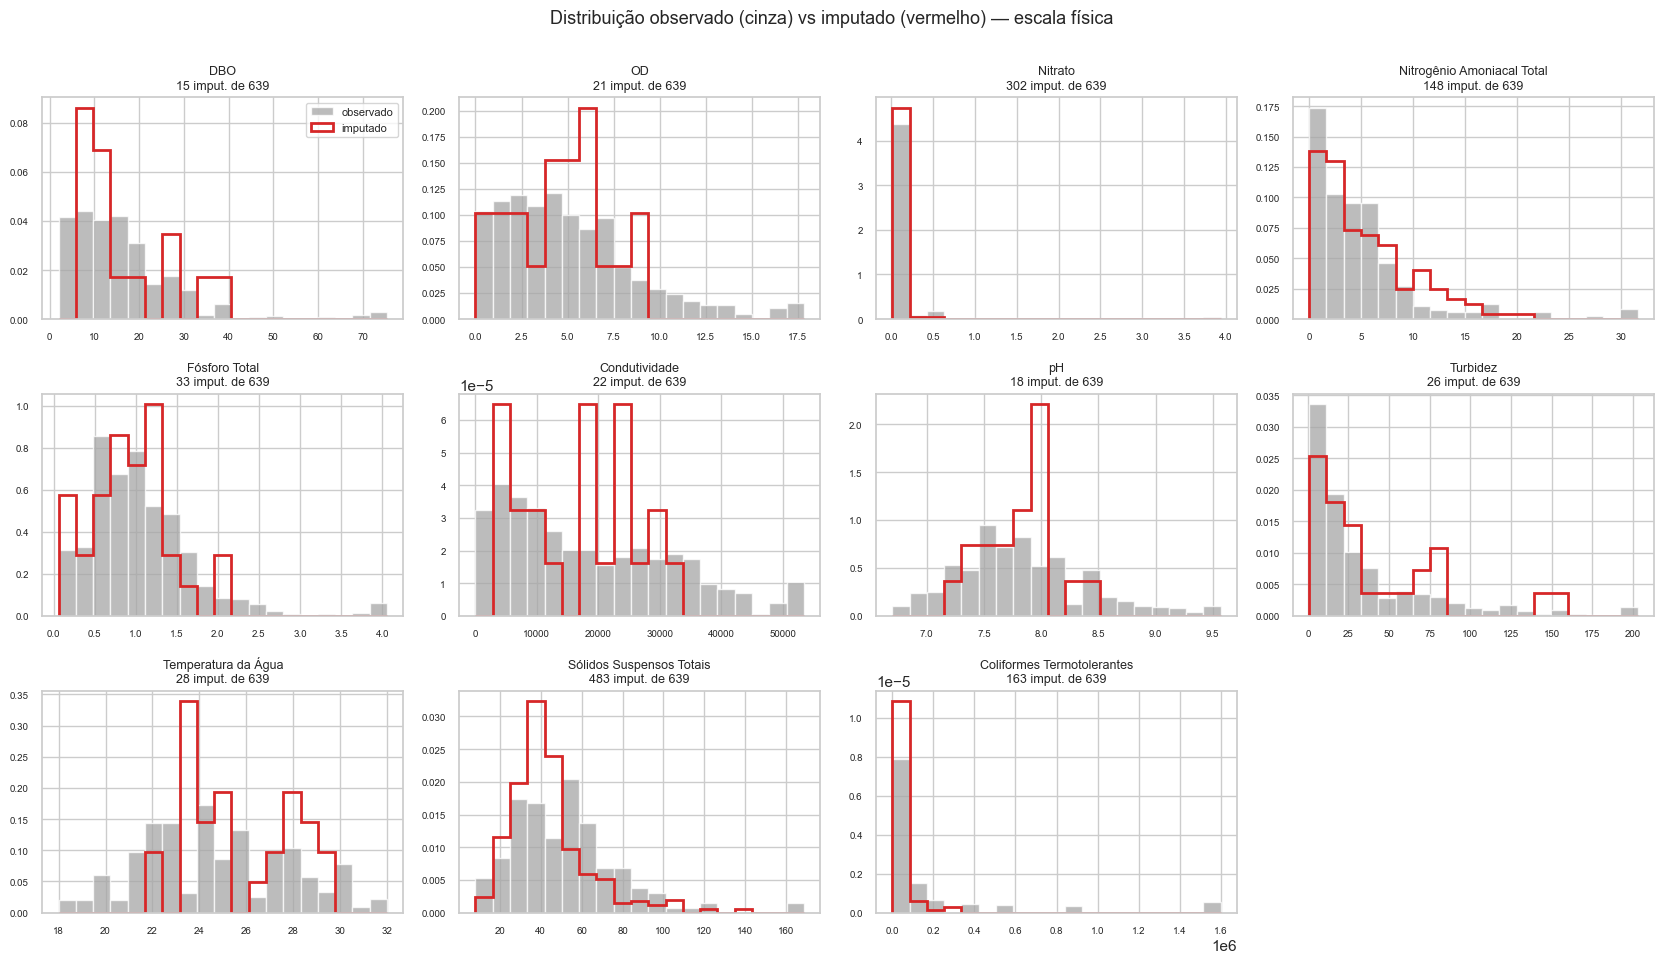

figura salva: distribuicao_imputado_vs_original.png


In [7]:
ncol = 4; nrow = int(np.ceil(len(VARS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, v in zip(axes, VARS):
    mv = M[v].values
    obs = orig[v].values[mv]; imp = imp_orig[v].values[~mv]
    obs = obs[~np.isnan(obs)]
    if len(obs) == 0: ax.axis("off"); continue
    lo, hi = np.percentile(obs, [1, 99])
    if hi <= lo: hi = lo + 1e-9
    bins = np.linspace(lo, hi, 20)
    ax.hist(np.clip(obs, lo, hi), bins=bins, density=True, color="0.65",
            alpha=0.75, label="observado")
    if len(imp):
        ax.hist(np.clip(imp, lo, hi), bins=bins, density=True, histtype="step",
                lw=2, color="#d62728", label="imputado")
    ax.set_title(f"{v}\n{int((~mv).sum())} imput. de {len(mv)}", fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[len(VARS):]: ax.axis("off")
axes[0].legend(fontsize=8)
fig.suptitle("Distribuição observado (cinza) vs imputado (vermelho) — escala física",
             y=1.002, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_FIG / "distribuicao_imputado_vs_original.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'distribuicao_imputado_vs_original.png').name}")

## 9. Persistência

In [8]:
final.to_parquet(OUT_PARQUET, index=False)
sz = OUT_PARQUET.stat().st_size / 1024
print(f"salvo: {OUT_PARQUET.relative_to(ROOT)}  ({final.shape[0]}×{final.shape[1]}, {sz:.0f} KB)")
# releitura de sanidade
chk = pd.read_parquet(OUT_PARQUET)
print(f"releitura: {chk.shape} | NaN nas variáveis: {int(chk[VARS].isna().sum().sum())}")

salvo: Data\ImputedData\WaterQualityImputed.parquet  (639×37, 50 KB)
releitura: (639, 37) | NaN nas variáveis: 0


## 10. Síntese

In [9]:
tot_imp = int(resumo["n_imputado"].sum())
tot_cel = int(resumo["n_original"].sum() + resumo["n_imputado"].sum())
mais = resumo.sort_values("pct_imputado", ascending=False).head(3)
print("DATASET IMPUTADO — WaterQualityImputed.parquet")
print("=" * 58)
print(f"Coletas ................. {final.shape[0]} (2012–2025, 6 estações)")
print(f"Variáveis sem NaN ....... {len(VARS)}/{len(VARS)}")
print(f"Células imputadas ....... {tot_imp} de {tot_cel} ({100*tot_imp/tot_cel:.1f}%)")
print("Mais imputadas:")
for _, r in mais.iterrows():
    print(f"   - {r['variavel']:28s} {int(r['n_imputado'])} ({r['pct_imputado']}%)")
print("\nUso: filtre `<Var>_imputed_flag == False` para restringir a medições.")
print("Ex.: df.loc[~df['DBO_imputed_flag'], 'DBO']  # só DBO medido")

DATASET IMPUTADO — WaterQualityImputed.parquet
Coletas ................. 639 (2012–2025, 6 estações)
Variáveis sem NaN ....... 11/11
Células imputadas ....... 1259 de 7029 (17.9%)
Mais imputadas:
   - Sólidos Suspensos Totais     483 (75.6%)
   - Nitrato                      302 (47.3%)
   - Coliformes Termotolerantes   163 (25.5%)

Uso: filtre `<Var>_imputed_flag == False` para restringir a medições.
Ex.: df.loc[~df['DBO_imputed_flag'], 'DBO']  # só DBO medido


### Leitura

O entregável central do projeto está pronto: um dataset **retangular e completo**, com
proveniência célula a célula via `_imputed_flag`. Pontos de atenção herdados da avaliação
(Etapa 5), que os notebooks seguintes devem respeitar:

- **SST e Nitrato** são os mais imputados (poucas medições originais) e os de imputação mais
  incerta — a GAIN empata/perde para baselines neles. Tratar análises que dependam fortemente
  dessas variáveis com cautela.
- **Caudas comprimidas:** os imputados são conservadores; um IQA ou tendência calculado sobre
  o dataset completo tende a **suavizar extremos**. Onde o extremo importa, reporte também a
  versão só-medições.

**Próximo notebook:** `02_iqa.ipynb` (índice de qualidade da água sobre o dataset imputado).